# Step.1 Notebook Overview

# Step.2 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
import seaborn as sns

# NLTK downloads (only first time)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Step.3 Load Dataset

In [2]:
file_path = r"C:\Users\admin\Desktop\Fintech_Complaint_Analysis\data\raw\complaints.csv"

selected_cols = [
    'Consumer complaint narrative',
    'Product',
    'Issue',
    'Company',
    'Date received'
]

df = pd.read_csv(
    file_path,
    usecols=selected_cols,
    nrows=30000
)

# Keep only rows with text
df = df[df['Consumer complaint narrative'].notnull()]
df.reset_index(drop=True, inplace=True)

df.head()


,Date received,Product,Issue,Consumer complaint narrative,Company
0,2025-10-14,Credit reporting or other personal consumer re...,Incorrect information on your report,My credit report contains incorrect and mislea...,"EQUIFAX, INC."
1,2025-10-26,Credit reporting or other personal consumer re...,Incorrect information on your report,Be sure that disputed accounts are taken down ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC."
2,2020-05-08,"Credit reporting, credit repair services, or o...",Incorrect information on your report,These are not my accounts.,Experian Information Solutions Inc.
3,2025-10-21,Credit reporting or other personal consumer re...,Incorrect information on your report,I do not recognize the aforementioned accounts...,"TRANSUNION INTERMEDIATE HOLDINGS, INC."
4,2025-11-10,Credit reporting or other personal consumer re...,Incorrect information on your report,I am formally disputing inaccurate information...,"TRANSUNION INTERMEDIATE HOLDINGS, INC."


# Step.4 Initial Text Inspection

In [3]:
# Check first few complaint texts
df['Consumer complaint narrative'].head(5)

0    My credit report contains incorrect and mislea...
1    Be sure that disputed accounts are taken down ...
2                           These are not my accounts.
3    I do not recognize the aforementioned accounts...
4    I am formally disputing inaccurate information...
Name: Consumer complaint narrative, dtype: object

In [4]:
# Basic text statistics
df['text_length'] = df['Consumer complaint narrative'].apply(len)
df['text_length'].describe()

count     3324.000000
mean      1075.572804
std       1149.050877
min         15.000000
25%        402.750000
50%        757.500000
75%       1332.250000
max      18523.000000
Name: text_length, dtype: float64

# Step.5 Text Cleaning Function

In [5]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Stopwords set
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    1. Lowercase
    2. Remove numbers
    3. Remove punctuation
    4. Remove extra spaces
    5. Tokenize
    6. Remove stopwords
    7. Lemmatize tokens
    8. Join back to string
    """
    if pd.isnull(text):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    
    # Join back to string
    cleaned_text = ' '.join(tokens)
    
    return cleaned_text


# Step.6 Apply Text Cleaning

In [6]:
# Apply cleaning function
df['cleaned_text'] = df['Consumer complaint narrative'].apply(clean_text)

# Quick look at cleaned text
df[['Consumer complaint narrative', 'cleaned_text']].head(5)


,Consumer complaint narrative,cleaned_text
0,My credit report contains incorrect and mislea...,credit report contains incorrect misleading item
1,Be sure that disputed accounts are taken down ...,sure disputed account taken promptly accordanc...
2,These are not my accounts.,account
3,I do not recognize the aforementioned accounts...,recognize aforementioned account collection ha...
4,I am formally disputing inaccurate information...,formally disputing inaccurate information cred...


# Step.7 Text Length After Cleaning

C:\Users\admin\Desktop\Fintech_Complaint_Analysis\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


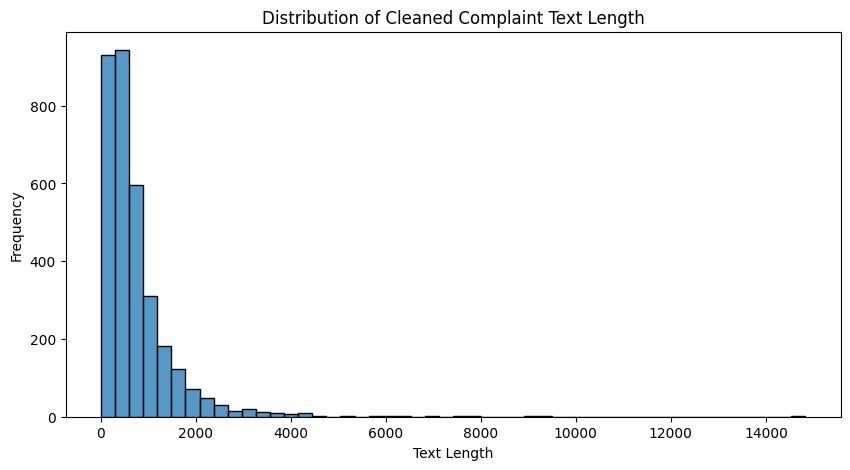

In [7]:
df['cleaned_text_length'] = df['cleaned_text'].apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['cleaned_text_length'], bins=50)
plt.title("Distribution of Cleaned Complaint Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


# Step.8 Word Frequency

In [8]:
from collections import Counter

all_words = ' '.join(df['cleaned_text']).split()
word_counts = Counter(all_words)

# Top 20 frequent words
word_counts.most_common(20)


[('xxxx', 47825),
 ('credit', 7693),
 ('account', 7331),
 ('report', 4544),
 ('reporting', 4108),
 ('information', 3973),
 ('xxxxxxxx', 3419),
 ('consumer', 3105),
 ('payment', 2561),
 ('fcra', 2084),
 ('usc', 1783),
 ('inaccurate', 1717),
 ('act', 1630),
 ('debt', 1568),
 ('fair', 1563),
 ('dispute', 1535),
 ('b', 1440),
 ('violation', 1427),
 ('inquiry', 1415),
 ('reported', 1386)]

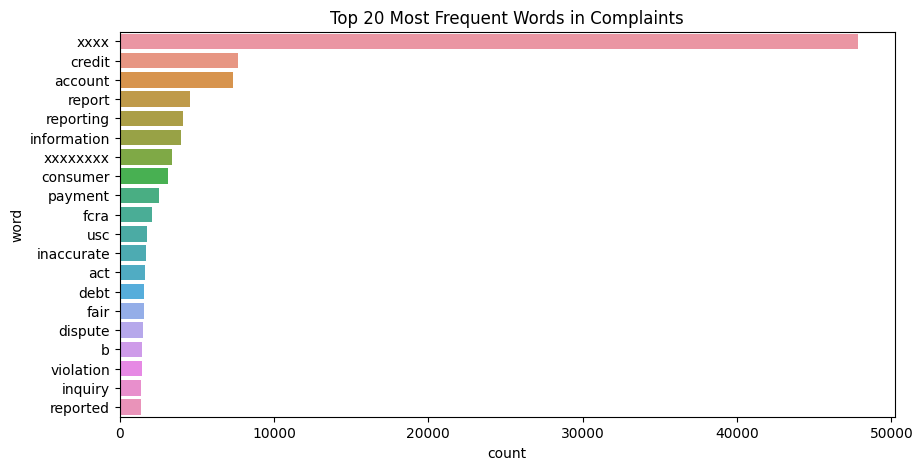

In [9]:
# Bar plot of top words
top_words = pd.DataFrame(word_counts.most_common(20), columns=['word','count'])
plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=top_words)
plt.title("Top 20 Most Frequent Words in Complaints")
plt.show()

# Step.9 Save Preprocessed Dataset

In [11]:
preprocessed_path = r"C:\Users\admin\Desktop\Fintech_Complaint_Analysis\data\processed\complaints_cleaned.csv"

df.to_csv(preprocessed_path, index=False)

print(f"✅ Preprocessed dataset saved at: {preprocessed_path}")


✅ Preprocessed dataset saved at: C:\Users\admin\Desktop\Fintech_Complaint_Analysis\data\processed\complaints_cleaned.csv


# Step.10 Summary